In [1]:
%pip install -q python-dotenv langchain_google_genai

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

query = "인프런에는 어떤 강의들이 있어?"

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
llm.invoke(query)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.2) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.2) which Google will stop supporting in new releases of google.ai.generativelanguage_v1beta once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.ai.generativelanguage_v1beta past that date.
  warnings.warn(message, FutureWarning)


AIMessage(content='인프런은 주로 **IT 개발 분야**에 특화된 온라인 강의 플랫폼이지만, 그 외에도 다양한 분야의 강의들을 폭넓게 제공하고 있습니다.\n\n주요 강의 카테고리는 다음과 같습니다:\n\n1.  **프로그래밍 언어 (Programming Languages):**\n    *   파이썬 (Python)\n    *   자바 (Java)\n    *   자바스크립트 (JavaScript)\n    *   C/C++\n    *   Go\n    *   Kotlin\n    *   Swift\n    *   PHP, Ruby 등 거의 모든 주요 언어 강의가 있습니다.\n\n2.  **웹 개발 (Web Development):**\n    *   **프론트엔드 (Frontend):** React, Vue.js, Angular, HTML/CSS, JavaScript 기초 등\n    *   **백엔드 (Backend):** Spring (스프링 부트), Node.js, Django, Flask, PHP, Ruby on Rails 등\n    *   **풀스택 (Fullstack) 개발:** 프론트엔드와 백엔드를 아우르는 강의\n    *   웹 퍼블리싱\n\n3.  **데이터 과학 / 인공지능 (Data Science / AI):**\n    *   데이터 분석 (파이썬, R 활용)\n    *   머신러닝 (Machine Learning)\n    *   딥러닝 (Deep Learning)\n    *   빅데이터 (Hadoop, Spark 등)\n    *   통계학 기초\n\n4.  **클라우드 (Cloud):**\n    *   AWS (Amazon Web Services)\n    *   Azure (Microsoft Azure)\n    *   Google Cloud Platform (GCP)\n    *   클라우드 아키텍처 및 서비스 활용\n\n5.  **데브옵스 / 인프라 (DevOps / Infrastructure):**

In [4]:
%pip install -q langgraph

I0704 02:04:24.045320  115152 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(92, generation: 1)
Note: you may need to restart the kernel to use updated packages.


In [5]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]]

In [6]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [8]:
def generate(state: AgentState) -> AgentState:
    messages = state["messages"]
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

graph_builder.add_node('generate', generate)

In [10]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [11]:
graph = graph_builder.compile()

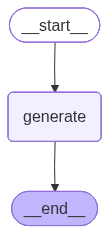

In [12]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}
graph.invoke(initial_state)

{'messages': [AIMessage(content='인프런(Inflearn)은 주로 **IT 및 개발 분야**에 특화된 실무 중심의 온라인 강의 플랫폼입니다. 현직 개발자나 전문가들이 직접 강의를 제작하고 판매하는 형태로 운영되기 때문에, 이론보다는 실제 프로젝트나 개발에 바로 적용할 수 있는 내용이 많습니다.\n\n주요 강의 카테고리는 다음과 같습니다:\n\n1.  **웹 개발 (Web Development)**\n    *   **프론트엔드 (Frontend):** HTML/CSS, JavaScript (바닐라 JS, ES6+), React, Vue.js, Angular, Next.js, TypeScript, Svelte 등\n    *   **백엔드 (Backend):** Java (Spring Boot), Python (Django, Flask), Node.js (Express), Go, PHP, C# (.NET), Ruby on Rails 등\n    *   **데이터베이스 (Database):** MySQL, PostgreSQL, MongoDB, Redis, Oracle 등\n    *   **웹 퍼블리싱:** 웹사이트 UI/UX 구현, 반응형 웹, 웹 접근성 등\n\n2.  **모바일 앱 개발 (Mobile App Development)**\n    *   **안드로이드 (Android):** Kotlin, Java\n    *   **iOS:** Swift, Objective-C\n    *   **크로스 플랫폼:** React Native, Flutter\n\n3.  **데이터 과학 / 인공지능 (Data Science / AI)**\n    *   **프로그래밍 언어:** Python (NumPy, Pandas, Scikit-learn), R\n    *   **머신러닝 (Machine Learning):** 지도학습, 비지도학습, 강화학습\n    *   **딥러닝 (Deep Learning):** TensorFlow, PyTorch